<a href="https://colab.research.google.com/github/Qudrat55/Html--Form/blob/main/Houseprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
file_path = "HousePricePrediction.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

display(df.head())
display(df.tail())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2919, 13)


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN



Column Names:
['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']

Data Types:
Id                int64
MSSubClass        int64
MSZoning         object
LotArea           int64
LotConfig        object
BldgType         object
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st      object
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object


In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,2919.0,NaN,NaN,NaN,1459.0,842.787043,0.0,729.5,1459.0,2188.5,2918.0
MSSubClass,2919.0,NaN,NaN,NaN,57.137718,42.517628,20.0,20.0,50.0,70.0,190.0
MSZoning,2915,5,RL,2265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotArea,2919.0,NaN,NaN,NaN,10168.11408,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
LotConfig,2919,5,Inside,2133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BldgType,2919,5,1Fam,2425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OverallCond,2919.0,NaN,NaN,NaN,5.564577,1.113131,1.0,5.0,5.0,6.0,9.0
YearBuilt,2919.0,NaN,NaN,NaN,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,NaN,NaN,NaN,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
Exterior1st,2918,15,VinylSd,1025,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nMissing Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing Values:
Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

Missing Percentage:
Id               0.00
MSSubClass       0.00
MSZoning         0.14
LotArea          0.00
LotConfig        0.00
BldgType         0.00
OverallCond      0.00
YearBuilt        0.00
YearRemodAdd     0.00
Exterior1st      0.03
BsmtFinSF2       0.03
TotalBsmtSF      0.03
SalePrice       49.98
dtype: float64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [ ]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Id: 2919 unique values
MSSubClass: 16 unique values
MSZoning: 5 unique values
LotArea: 1951 unique values
LotConfig: 5 unique values
BldgType: 5 unique values
OverallCond: 9 unique values
YearBuilt: 118 unique values
YearRemodAdd: 61 unique values
Exterior1st: 15 unique values
BsmtFinSF2: 272 unique values
TotalBsmtSF: 1058 unique values
SalePrice: 663 unique values


In [ ]:
categorical_features = [
    "MSSubClass",
    "MSZoning",
    "LotConfig",
    "BldgType",
    "Exterior1st"
]

numerical_features = [
    "LotArea",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "BsmtFinSF2",
    "TotalBsmtSF"
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['MSSubClass', 'MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']

Numerical Features:
['LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF']


In [ ]:
target = "SalePrice"

print("Target Variable:", target)
print("Available target values:", df[target].notna().sum())
print("Missing target values:", df[target].isna().sum())

Target Variable: SalePrice
Available target values: 1460
Missing target values: 1459


In [ ]:
labeled_df = df[df["SalePrice"].notna()].copy()

print("Labeled Dataset Shape:", labeled_df.shape)

Labeled Dataset Shape: (1460, 13)


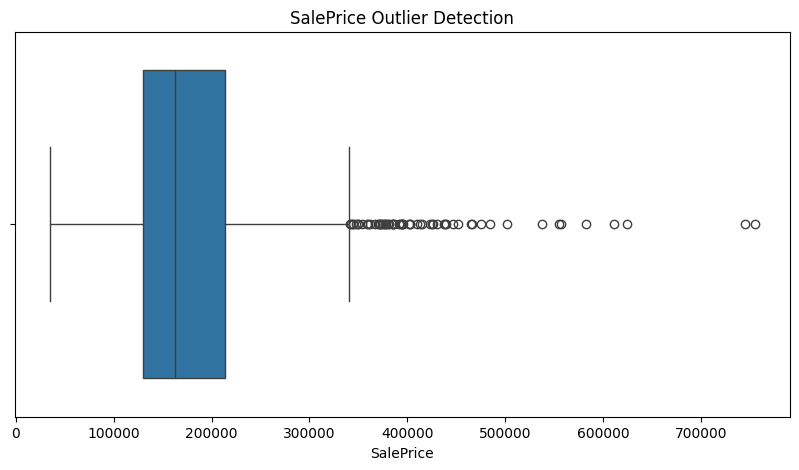

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=labeled_df["SalePrice"])

plt.title("SalePrice Outlier Detection")
plt.xlabel("SalePrice")

plt.show()

In [14]:
Q1 = labeled_df["SalePrice"].quantile(0.25)
Q3 = labeled_df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = labeled_df[
    (labeled_df["SalePrice"] < lower_bound) |
    (labeled_df["SalePrice"] > upper_bound)
]

print("Number of SalePrice outliers:", len(outliers))

Number of SalePrice outliers: 61


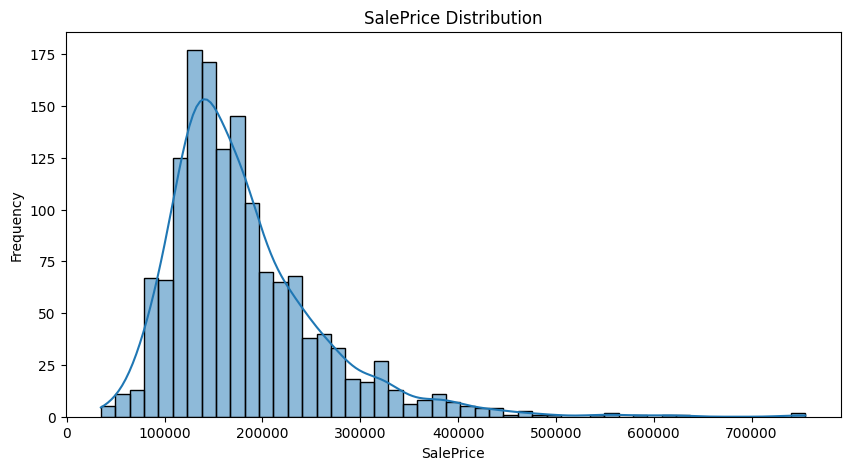

SalePrice Skewness: 1.8828757597682129


In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(labeled_df["SalePrice"], kde=True)

plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.show()

print("SalePrice Skewness:",
      labeled_df["SalePrice"].skew())

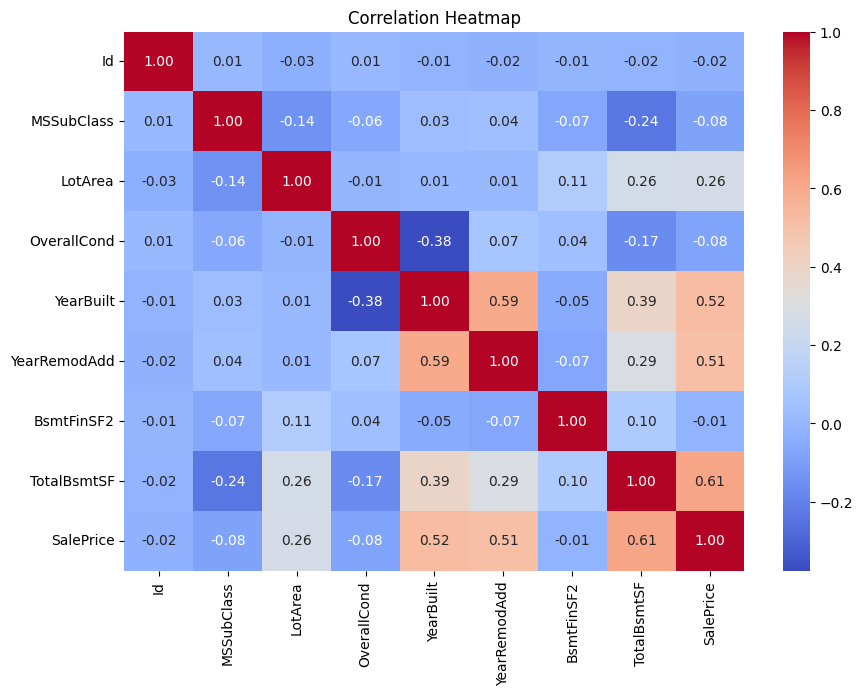

In [16]:
correlation = labeled_df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
X = labeled_df.drop(
    columns=["SalePrice", "Id"]
)

y = labeled_df["SalePrice"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1460, 11)
y Shape: (1460,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1168, 11)
Testing Data: (292, 11)


In [19]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

Linear Regression preprocessing

In [20]:
preprocessor_lr = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

Tree models preprocessing

In [21]:
numeric_tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_tree_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [22]:
linear_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model", LinearRegression())
])

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeRegressor(
        random_state=42
    ))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [23]:
linear_model.fit(X_train, y_train)

decision_tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [24]:
linear_pred = linear_model.predict(X_test)

tree_pred = decision_tree_model.predict(X_test)

forest_pred = random_forest_model.predict(X_test)

In [25]:
prediction_comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Linear Regression": linear_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred
})

display(prediction_comparison.head(10))

,Actual Price,Linear Regression,Decision Tree,Random Forest
0,154500.0,166244.497993,154000.0,149366.040000
1,325000.0,261263.339991,262280.0,287557.150000
2,115000.0,107844.347941,110500.0,119258.000000
3,159000.0,169308.851937,151400.0,135074.430000
4,315500.0,246405.774269,220000.0,285562.786667
5,75500.0,104372.762551,88000.0,95332.303333
6,311500.0,176979.581685,164900.0,235823.666667
7,146000.0,132866.407118,148500.0,142201.070000
8,84500.0,95739.308554,88000.0,93953.136667
9,135500.0,158626.980887,239000.0,180164.266667


In [26]:
residual_df = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Regression": linear_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred
})

residual_df["LR Residual"] = (
    residual_df["Actual"] -
    residual_df["Linear Regression"]
)

residual_df["DT Residual"] = (
    residual_df["Actual"] -
    residual_df["Decision Tree"]
)

residual_df["RF Residual"] = (
    residual_df["Actual"] -
    residual_df["Random Forest"]
)

display(residual_df.head(10))

,Actual,Linear Regression,Decision Tree,Random Forest,LR Residual,DT Residual,RF Residual
0,154500.0,166244.497993,154000.0,149366.040000,-11744.497993,500.0,5133.960000
1,325000.0,261263.339991,262280.0,287557.150000,63736.660009,62720.0,37442.850000
2,115000.0,107844.347941,110500.0,119258.000000,7155.652059,4500.0,-4258.000000
3,159000.0,169308.851937,151400.0,135074.430000,-10308.851937,7600.0,23925.570000
4,315500.0,246405.774269,220000.0,285562.786667,69094.225731,95500.0,29937.213333
5,75500.0,104372.762551,88000.0,95332.303333,-28872.762551,-12500.0,-19832.303333
6,311500.0,176979.581685,164900.0,235823.666667,134520.418315,146600.0,75676.333333
7,146000.0,132866.407118,148500.0,142201.070000,13133.592882,-2500.0,3798.930000
8,84500.0,95739.308554,88000.0,93953.136667,-11239.308554,-3500.0,-9453.136667
9,135500.0,158626.980887,239000.0,180164.266667,-23126.980887,-103500.0,-44664.266667


In [27]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    }


results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree Regressor",
        y_test,
        tree_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest Regressor",
        y_test,
        forest_pred
    )
)

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,32027.882269,2.569602e+09,50691.239834,0.664994
1,Decision Tree Regressor,30690.034247,2.072829e+09,45528.336652,0.729760
2,Random Forest Regressor,22296.733431,1.291935e+09,35943.492344,0.831567


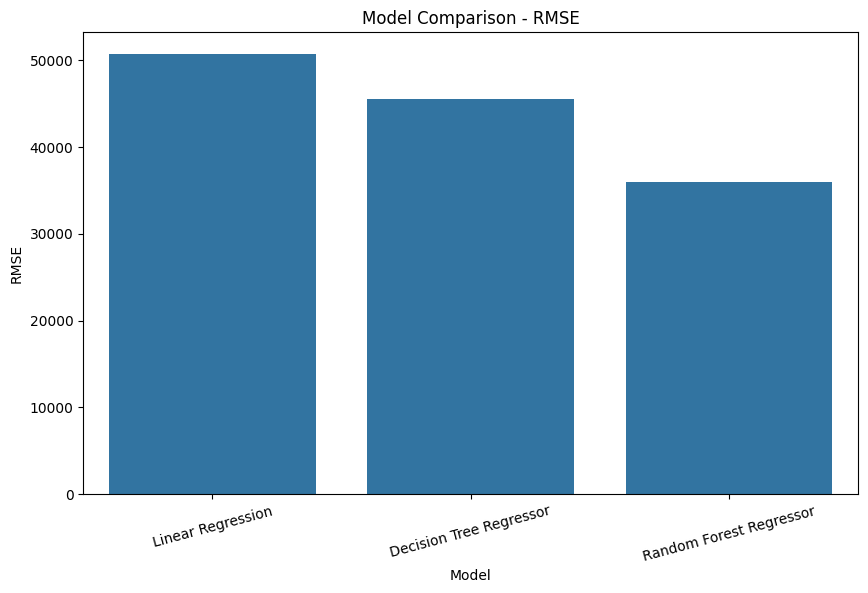

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison - RMSE")
plt.xticks(rotation=15)

plt.show()

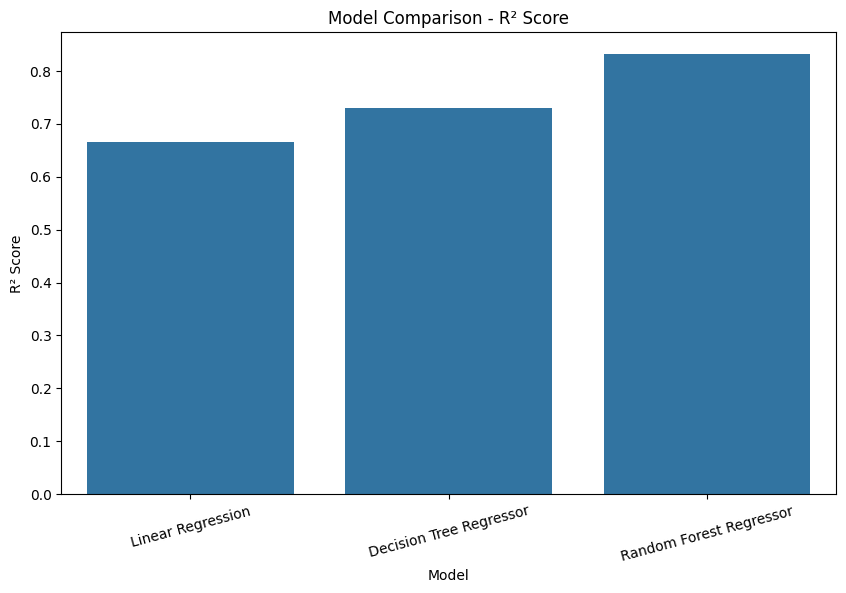

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison - R² Score")
plt.xticks(rotation=15)

plt.show()

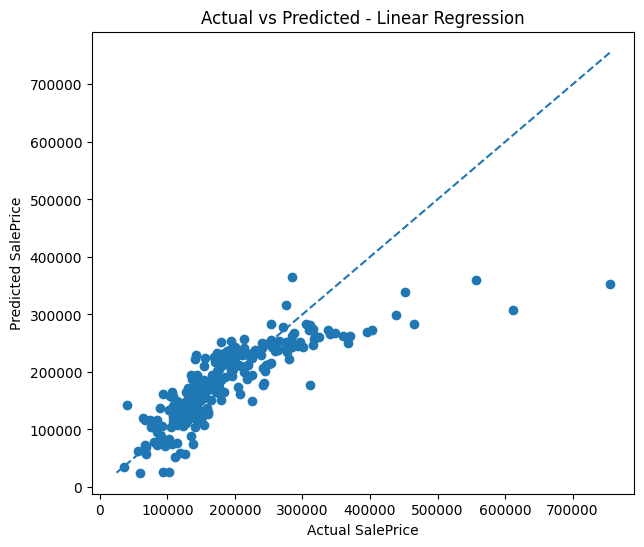

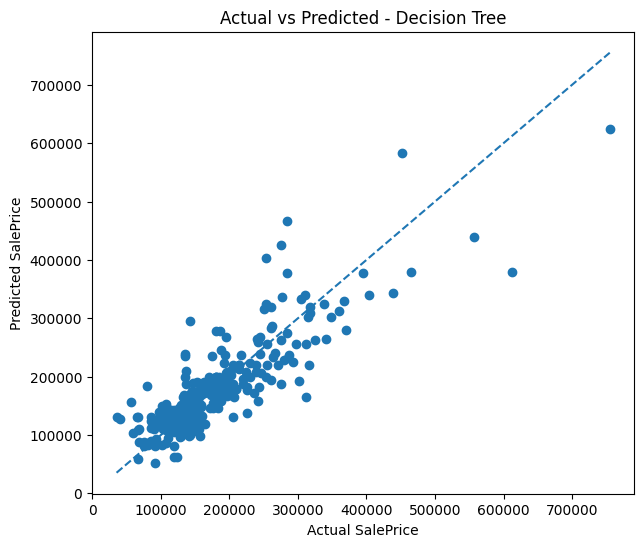

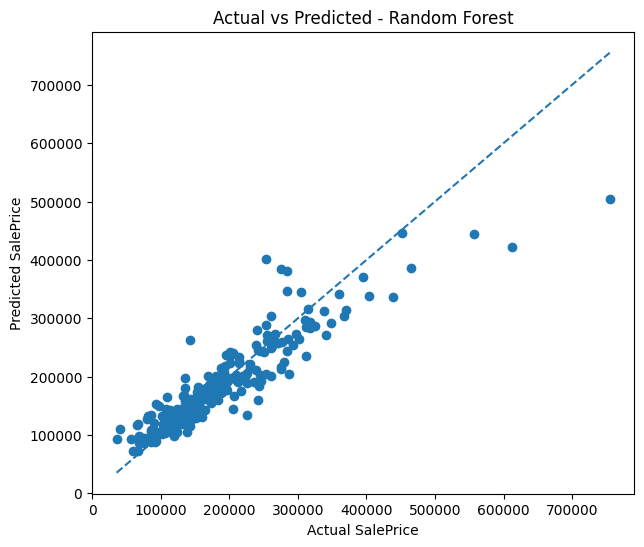

In [30]:
predictions = {
    "Linear Regression": linear_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred
}

for name, prediction in predictions.items():

    plt.figure(figsize=(7, 6))

    plt.scatter(y_test, prediction)

    min_value = min(y_test.min(), prediction.min())
    max_value = max(y_test.max(), prediction.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Actual SalePrice")
    plt.ylabel("Predicted SalePrice")
    plt.title(f"Actual vs Predicted - {name}")

    plt.show()

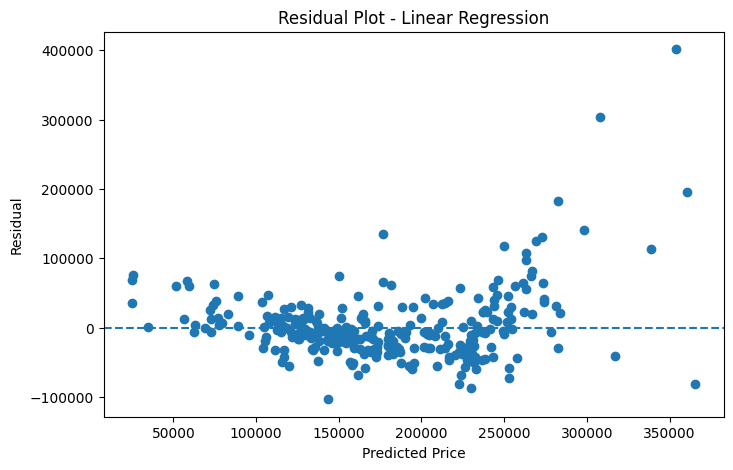

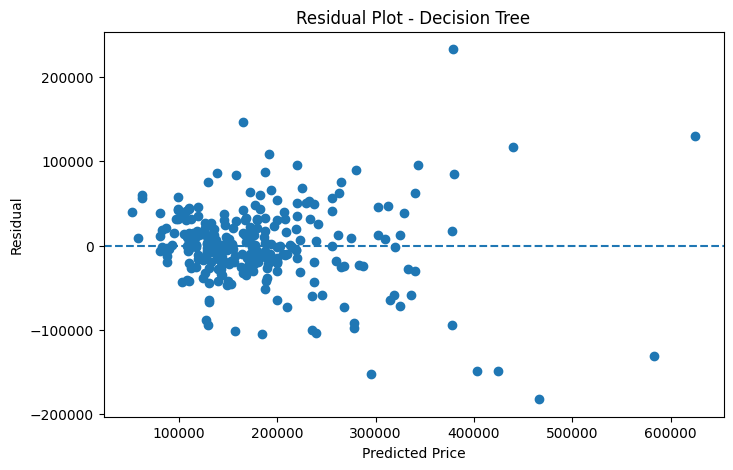

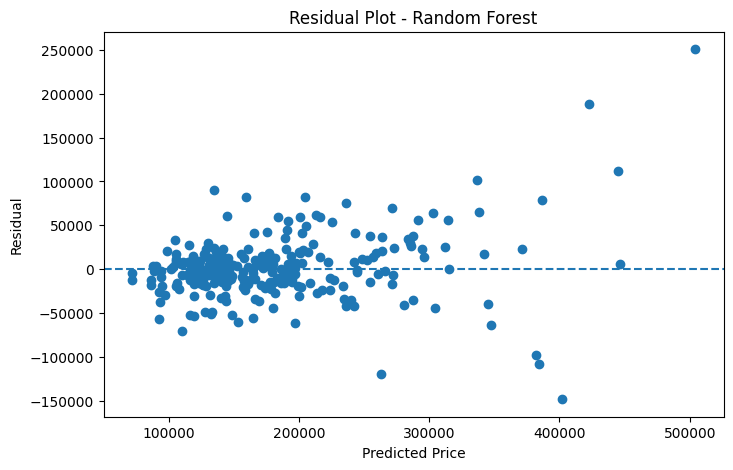

In [31]:
for name, prediction in predictions.items():

    residuals = y_test.values - prediction

    plt.figure(figsize=(8, 5))

    plt.scatter(prediction, residuals)

    plt.axhline(
        y=0,
        linestyle="--"
    )

    plt.xlabel("Predicted Price")
    plt.ylabel("Residual")
    plt.title(f"Residual Plot - {name}")

    plt.show()

In [32]:
models_dict = {
    "Linear Regression": linear_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

overfitting_results = []

for name, model in models_dict.items():

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_r2 = r2_score(y_train, train_prediction)
    test_r2 = r2_score(y_test, test_prediction)

    overfitting_results.append({
        "Model": name,
        "Training R²": train_r2,
        "Testing R²": test_r2,
        "Difference": train_r2 - test_r2
    })

overfitting_df = pd.DataFrame(overfitting_results)

display(overfitting_df)

,Model,Training R²,Testing R²,Difference
0,Linear Regression,0.655135,0.664994,-0.009859
1,Decision Tree,0.999978,0.729760,0.270218
2,Random Forest,0.967744,0.831567,0.136177


In [33]:
tree_preprocessor = decision_tree_model.named_steps["preprocessor"]
tree_model = decision_tree_model.named_steps["model"]

tree_feature_names = tree_preprocessor.get_feature_names_out()

tree_importance = pd.Series(
    tree_model.feature_importances_,
    index=tree_feature_names
).sort_values(ascending=False)

display(tree_importance.head(10))

,0
num__YearBuilt,0.350514
num__TotalBsmtSF,0.282199
num__LotArea,0.150765
cat__MSSubClass_60,0.062722
num__YearRemodAdd,0.036247
num__OverallCond,0.031325
cat__Exterior1st_Wd Sdng,0.020930
cat__Exterior1st_BrkFace,0.008493
cat__MSSubClass_30,0.006715
cat__Exterior1st_Stucco,0.006660


In [34]:
forest_preprocessor = random_forest_model.named_steps["preprocessor"]
forest_model = random_forest_model.named_steps["model"]

forest_feature_names = forest_preprocessor.get_feature_names_out()

forest_importance = pd.Series(
    forest_model.feature_importances_,
    index=forest_feature_names
).sort_values(ascending=False)

display(forest_importance.head(10))

,0
num__TotalBsmtSF,0.331823
num__YearBuilt,0.303556
num__LotArea,0.131036
cat__MSSubClass_60,0.076955
num__YearRemodAdd,0.046489
num__OverallCond,0.027042
cat__Exterior1st_Wd Sdng,0.011783
cat__Exterior1st_BrkFace,0.009129
cat__MSSubClass_30,0.005523
cat__MSSubClass_70,0.005146


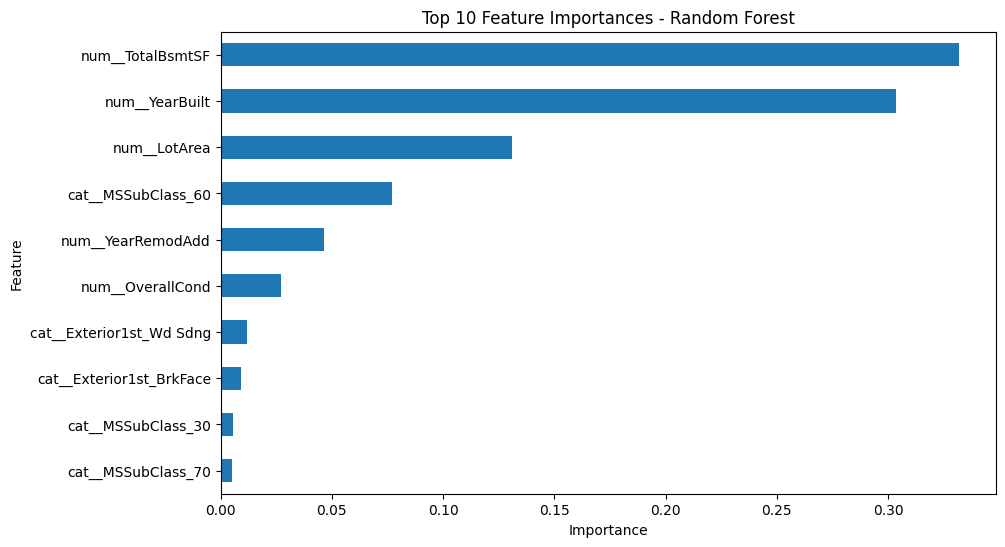

In [35]:
top_features = forest_importance.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_features.plot(kind="barh")

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()